In [1]:
# In[1]: 导入库

import numpy as np
import pandas as pd

# 可视化相关
import matplotlib.pyplot as plt
import seaborn as sns

# 机器学习相关
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [2]:
# In[2]: 加载数据

# 你需要先将train.csv和test.csv放置在当前工作目录下，或者使用完整路径
train_data = pd.read_csv("train.csv")
test_data = pd.read_csv("test.csv")

# 查看数据基本情况
print("训练集大小:", train_data.shape)
print("测试集大小:", test_data.shape)

train_data.head()


训练集大小: (891, 12)
测试集大小: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# In[3]: 数据探索与预处理

# 检查缺失值
print("训练集缺失值：")
print(train_data.isnull().sum())
print("\n测试集缺失值：")
print(test_data.isnull().sum())

# 在Titanic数据集中，常见缺失字段有Age、Cabin、Embarked、Fare等
# 在本示例中，我们主要处理Age、Embarked、Fare的缺失值

# 填充缺失值（训练集）
train_data['Age'] = train_data['Age'].fillna(train_data['Age'].median())
train_data.fillna({'Embarked': train_data['Embarked'].mode()[0]})
# Cabin 缺失值很多，此处我们简单删除该字段，也可以选择提取有无Cabin等更复杂的特征
train_data.drop('Cabin', axis=1, inplace=True)

# 填充缺失值（测试集）
test_data['Age'] = test_data['Age'].fillna(test_data['Age'].median())
test_data['Fare'] = test_data['Fare'].fillna(test_data['Fare'].median())
test_data['Embarked'] = test_data['Embarked'].fillna(test_data['Embarked'].mode()[0])
test_data.drop('Cabin', axis=1, inplace=True)


训练集缺失值：
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

测试集缺失值：
PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


In [4]:
# In[4]: 特征工程

# 将Sex转换为数值：{male: 0, female: 1}
train_data['Sex'] = train_data['Sex'].map({'male': 0, 'female': 1})
test_data['Sex'] = test_data['Sex'].map({'male': 0, 'female': 1})

# 对Embarked进行独热编码
train_data = pd.get_dummies(train_data, columns=['Embarked'], drop_first=True)
test_data = pd.get_dummies(test_data, columns=['Embarked'], drop_first=True)

# 提取特征列
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 
            'Embarked_Q', 'Embarked_S']  # Embarked_C 被drop_first去掉

X = train_data[features]
y = train_data['Survived']
X_test = test_data[features]

# 也可以进行更多的特征工程，如从Name提取称谓、增加FamilySize等
# 此处仅演示基础操作

# 特征标准化（随机森林对是否标准化不太敏感，但在实际场景中常规操作是对数值特征做标准化）
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)


In [5]:
# In[5]: 训练集与验证集拆分

X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("训练集大小:", X_train.shape)
print("验证集大小:", X_val.shape)


训练集大小: (712, 8)
验证集大小: (179, 8)


In [6]:
# In[6]: 训练随机森林模型

# 使用默认参数进行初步训练
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 在验证集上预测
y_val_pred = rf.predict(X_val)
val_accuracy = accuracy_score(y_val, y_val_pred)

print(f"验证集准确率: {val_accuracy:.4f}")


验证集准确率: 0.8045


In [7]:
# In[7]: 模型优化 - 网格搜索 (可选)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)
print("最优参数:", grid_search.best_params_)
print("最优模型交叉验证准确率:", grid_search.best_score_)

# 使用最优模型评估验证集表现
best_rf = grid_search.best_estimator_
y_val_pred_best = best_rf.predict(X_val)
val_accuracy_best = accuracy_score(y_val, y_val_pred_best)
print(f"验证集准确率 (最优模型): {val_accuracy_best:.4f}")


Fitting 5 folds for each of 27 candidates, totalling 135 fits
最优参数: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}
最优模型交叉验证准确率: 0.832837584950261
验证集准确率 (最优模型): 0.8156


In [8]:
# In[8]: 使用最优模型生成提交文件

# 如果你对当前best_rf满意，就用它在测试集上做预测
# 如果你想使用原始rf，也可以替换为rf模型
y_test_pred = best_rf.predict(X_test_scaled)

submission = pd.DataFrame({
    "PassengerId": test_data["PassengerId"],
    "Survived": y_test_pred
})

submission.to_csv("titanic_rf_submission.csv", index=False)
print("提交文件已生成： titanic_rf_submission.csv")


提交文件已生成： titanic_rf_submission.csv


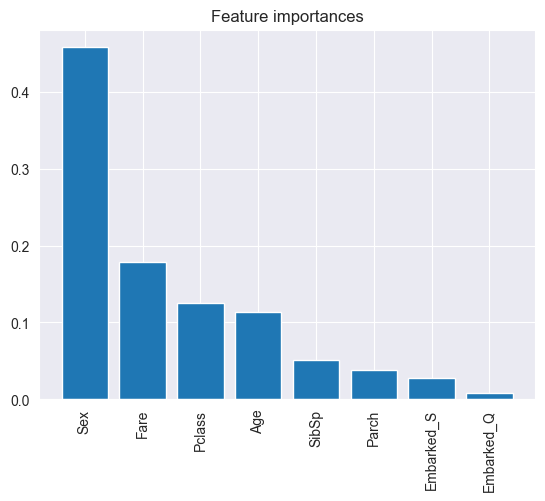

In [9]:
# In[9]: 可视化特征重要性（可选）

importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]
features_sorted = [features[i] for i in indices]
plt.figure()
plt.title("Feature importances")
plt.bar(range(X.shape[1]), importances[indices])
plt.xticks(range(X.shape[1]), features_sorted, rotation=90)
plt.show()

In [10]:
# In[10]: 模型评估（可选）

from sklearn.metrics import confusion_matrix, classification_report

print("混淆矩阵:")
print(confusion_matrix(y_val, y_val_pred_best))

print("\n分类报告:")
print(classification_report(y_val, y_val_pred_best))

混淆矩阵:
[[94 11]
 [22 52]]

分类报告:
              precision    recall  f1-score   support

           0       0.81      0.90      0.85       105
           1       0.83      0.70      0.76        74

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.80       179
weighted avg       0.82      0.82      0.81       179

